In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/upi_transactions.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Shape: (500000, 22)
Columns: ['transaction_id', 'timestamp', 'sender_vpa', 'receiver_vpa', 'sender_bank', 'receiver_bank', 'sender_bank_encoded', 'receiver_bank_encoded', 'hour_of_day', 'day_of_week', 'is_salary_day', 'is_festival_day', 'amount', 'amount_bucket', 'device_type', 'network_type', 'sender_bank_health', 'receiver_bank_health', 'sender_recent_fail_rate', 'receiver_recent_fail_rate', 'failure_reason_code', 'is_failed']


,transaction_id,timestamp,sender_vpa,receiver_vpa,sender_bank,receiver_bank,sender_bank_encoded,receiver_bank_encoded,hour_of_day,day_of_week,...,amount,amount_bucket,device_type,network_type,sender_bank_health,receiver_bank_health,sender_recent_fail_rate,receiver_recent_fail_rate,failure_reason_code,is_failed
0,c38dea2f-ee4a-4af0-a9b1-ab89cc65c8b4,2025-10-27 04:47:17,9600133890@okhdfc,8386379402@okhdfc,HDFC,HDFC,1,1,4,0,...,1207.20,medium,android,2G,0.93,0.88,0.02,0.05,NaN,0
1,60bd302b-1fba-46f1-9e94-2f93ec1289f3,2025-10-12 12:17:09,5940781618@okhdfc,4959310341@okpnb,HDFC,PNB,1,6,12,6,...,1275.47,medium,android,4G,0.95,0.79,0.02,0.19,NaN,0
2,19469d89-681f-4b8a-8173-bdad7eb09b2c,2026-02-08 21:24:17,1928327648@okaxis,3503056413@okpnb,Axis,PNB,3,6,21,6,...,1362.76,medium,android,4G,0.64,0.64,0.04,0.11,NaN,0


In [2]:
# Peak hours: 9-11 AM and 7-10 PM (highest UPI traffic)
df['is_peak_hour'] = df['hour_of_day'].apply(
    lambda x: 1 if (9 <= x <= 11) or (19 <= x <= 22) else 0
)

# Weekend flag
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# High stress day — salary OR festival
df['is_high_stress_day'] = ((df['is_salary_day'] == 1) | (df['is_festival_day'] == 1)).astype(int)

print("Peak hour distribution:")
print(df['is_peak_hour'].value_counts())
print(f"\nPeak hour failure rate:     {df[df['is_peak_hour']==1]['is_failed'].mean()*100:.2f}%")
print(f"Non-peak hour failure rate: {df[df['is_peak_hour']==0]['is_failed'].mean()*100:.2f}%")
print(f"\nHigh stress day failure rate: {df[df['is_high_stress_day']==1]['is_failed'].mean()*100:.2f}%")
print(f"Normal day failure rate:      {df[df['is_high_stress_day']==0]['is_failed'].mean()*100:.2f}%")

Peak hour distribution:
is_peak_hour
0    307522
1    192478
Name: count, dtype: int64

Peak hour failure rate:     35.58%
Non-peak hour failure rate: 25.32%

High stress day failure rate: 42.34%
Normal day failure rate:      27.26%


In [3]:
# Log transform — reduces right skew of amount
df['log_amount'] = np.log1p(df['amount'])

# High value transaction flag
df['is_high_value'] = (df['amount'] > 10000).astype(int)

print("High value transaction distribution:")
print(df['is_high_value'].value_counts())
print(f"\nHigh value failure rate:  {df[df['is_high_value']==1]['is_failed'].mean()*100:.2f}%")
print(f"Normal value failure rate: {df[df['is_high_value']==0]['is_failed'].mean()*100:.2f}%")

# Verify log transform reduced skew
print(f"\nAmount skew (original): {df['amount'].skew():.3f}")
print(f"Amount skew (log):      {df['log_amount'].skew():.3f}")

High value transaction distribution:
is_high_value
0    494116
1      5884
Name: count, dtype: int64

High value failure rate:  35.01%
Normal value failure rate: 29.20%

Amount skew (original): 9.112
Amount skew (log):      0.013


In [4]:
# Difference in bank health — if sender is weak but receiver is strong, still risky
df['bank_health_diff'] = df['sender_bank_health'] - df['receiver_bank_health']

# Combined fail rate — average of both sides
df['combined_fail_rate'] = (df['sender_recent_fail_rate'] + df['receiver_recent_fail_rate']) / 2

# Weakest link — minimum health on either side
df['min_bank_health'] = df[['sender_bank_health', 'receiver_bank_health']].min(axis=1)

# Health × fail rate interaction — most powerful feature
df['health_x_failrate'] = df['sender_bank_health'] * df['sender_recent_fail_rate']

print("New interaction features created:")
print(df[['bank_health_diff', 'combined_fail_rate', 'min_bank_health', 'health_x_failrate']].describe().round(3))

New interaction features created:
       bank_health_diff  combined_fail_rate  min_bank_health  \
count        500000.000          500000.000       500000.000   
mean             -0.021               0.162            0.748   
std               0.117               0.098            0.088   
min              -0.470               0.000            0.270   
25%              -0.100               0.085            0.690   
50%              -0.020               0.150            0.750   
75%               0.060               0.220            0.810   
max               0.470               0.820            0.950   

       health_x_failrate  
count         500000.000  
mean               0.132  
std                0.107  
min                0.000  
25%                0.048  
50%                0.109  
75%                0.193  
max                0.788  


In [5]:
# Network type risk mapping (from EDA — 2G/3G had higher failure)
network_risk = {'2G': 1.0, '3G': 0.6, '4G': 0.2, 'WiFi': 0.0}
df['network_risk'] = df['network_type'].map(network_risk)

# Sender risk score — weighted combination
# Higher bank fail rate + lower health + risky network = high risk
df['sender_risk_score'] = (
    0.4 * df['sender_recent_fail_rate'] +
    0.3 * (1 - df['sender_bank_health']) +   # invert health: low health = high risk
    0.2 * df['network_risk'] +
    0.1 * df['is_high_value']
)

print("Sender risk score stats:")
print(df['sender_risk_score'].describe().round(3))
print(f"\nHigh risk (score > 0.5) failure rate: {df[df['sender_risk_score'] > 0.5]['is_failed'].mean()*100:.2f}%")
print(f"Low risk  (score < 0.2) failure rate: {df[df['sender_risk_score'] < 0.2]['is_failed'].mean()*100:.2f}%")

Sender risk score stats:
count    409857.000
mean          0.226
std           0.095
min           0.055
25%           0.154
50%           0.218
75%           0.289
max           0.652
Name: sender_risk_score, dtype: float64

High risk (score > 0.5) failure rate: 57.55%
Low risk  (score < 0.2) failure rate: 21.52%


In [6]:
# One-hot encode network_type, device_type, amount_bucket
df = pd.get_dummies(df, columns=['network_type', 'device_type', 'amount_bucket'], drop_first=False)

print("Shape after encoding:", df.shape)
print("\nNew columns added:")
new_cols = [c for c in df.columns if any(x in c for x in ['network_type_', 'device_type_', 'amount_bucket_'])]
print(new_cols)

Shape after encoding: (500000, 42)

New columns added:
['network_type_2G', 'network_type_3G', 'network_type_4G', 'network_type_wifi', 'device_type_android', 'device_type_feature_phone', 'device_type_ios', 'amount_bucket_large', 'amount_bucket_medium', 'amount_bucket_micro', 'amount_bucket_small', 'amount_bucket_very_large']


In [7]:
df.columns

Index(['transaction_id', 'timestamp', 'sender_vpa', 'receiver_vpa',
       'sender_bank', 'receiver_bank', 'sender_bank_encoded',
       'receiver_bank_encoded', 'hour_of_day', 'day_of_week', 'is_salary_day',
       'is_festival_day', 'amount', 'sender_bank_health',
       'receiver_bank_health', 'sender_recent_fail_rate',
       'receiver_recent_fail_rate', 'failure_reason_code', 'is_failed',
       'is_peak_hour', 'is_weekend', 'is_high_stress_day', 'log_amount',
       'is_high_value', 'bank_health_diff', 'combined_fail_rate',
       'min_bank_health', 'health_x_failrate', 'network_risk',
       'sender_risk_score', 'network_type_2G', 'network_type_3G',
       'network_type_4G', 'network_type_wifi', 'device_type_android',
       'device_type_feature_phone', 'device_type_ios', 'amount_bucket_large',
       'amount_bucket_medium', 'amount_bucket_micro', 'amount_bucket_small',
       'amount_bucket_very_large'],
      dtype='object')

In [8]:
drop_cols = [
    'transaction_id',   # just an ID
    'timestamp',        # already extracted hour, day
    'sender_vpa',       # high cardinality, no signal
    'receiver_vpa',     # high cardinality, no signal
    'sender_bank',      # already have sender_bank_encoded
    'receiver_bank',    # already have receiver_bank_encoded
    'hour_of_day',      # already have is_peak_hour
    'failure_reason_code'  # TARGET LEAKAGE — only exists when is_failed=1
]

df_model = df.drop(columns=drop_cols)

print(f"Shape before drop: {df.shape}")
print(f"Shape after drop:  {df_model.shape}")
print(f"\nFinal features ({df_model.shape[1]-1} features + 1 target):")
feature_cols = [c for c in df_model.columns if c != 'is_failed']
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2}. {col}")

Shape before drop: (500000, 42)
Shape after drop:  (500000, 34)

Final features (33 features + 1 target):
   1. sender_bank_encoded
   2. receiver_bank_encoded
   3. day_of_week
   4. is_salary_day
   5. is_festival_day
   6. amount
   7. sender_bank_health
   8. receiver_bank_health
   9. sender_recent_fail_rate
  10. receiver_recent_fail_rate
  11. is_peak_hour
  12. is_weekend
  13. is_high_stress_day
  14. log_amount
  15. is_high_value
  16. bank_health_diff
  17. combined_fail_rate
  18. min_bank_health
  19. health_x_failrate
  20. network_risk
  21. sender_risk_score
  22. network_type_2G
  23. network_type_3G
  24. network_type_4G
  25. network_type_wifi
  26. device_type_android
  27. device_type_feature_phone
  28. device_type_ios
  29. amount_bucket_large
  30. amount_bucket_medium
  31. amount_bucket_micro
  32. amount_bucket_small
  33. amount_bucket_very_large


In [9]:
# Quick check — make sure no column is perfectly correlated with target
correlations = df_model.corr()['is_failed'].abs().sort_values(ascending=False)

print("Top 10 correlations with is_failed:")
print(correlations.head(11).round(3))  # 11 because is_failed itself is #1

# Red flag: if any feature has correlation > 0.95, it's likely leakage
leakage_check = correlations[correlations > 0.95].drop('is_failed')
if len(leakage_check) > 0:
    print(f"\n⚠️  POTENTIAL LEAKAGE DETECTED: {list(leakage_check.index)}")
else:
    print("\n✅ No target leakage detected")

Top 10 correlations with is_failed:
is_failed                  1.000
sender_risk_score          0.213
sender_bank_health         0.179
min_bank_health            0.170
network_risk               0.132
sender_recent_fail_rate    0.117
is_high_stress_day         0.113
network_type_2G            0.111
is_peak_hour               0.110
receiver_bank_health       0.108
is_salary_day              0.100
Name: is_failed, dtype: float64

✅ No target leakage detected


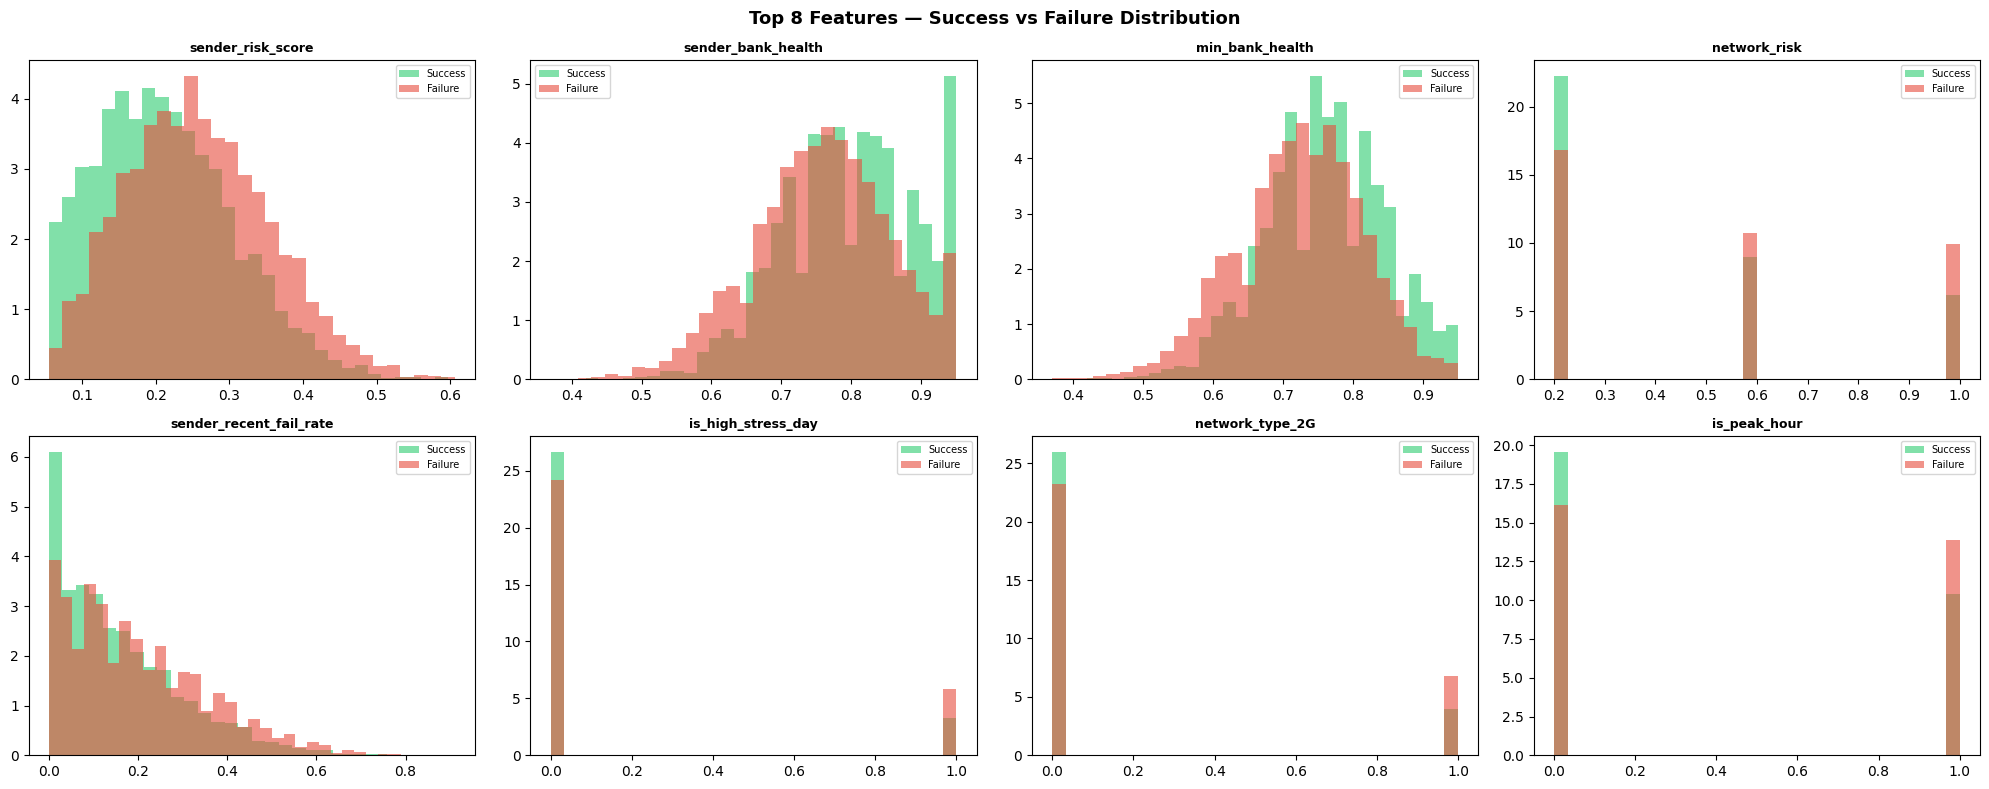

✅ Saved: 09_top_features_distribution.png


In [10]:
top_features = correlations.drop('is_failed').head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    failed = df_model[df_model['is_failed'] == 1][col].astype(float)
    success = df_model[df_model['is_failed'] == 0][col].astype(float)
    axes[i].hist(success.sample(min(5000, len(success)), random_state=42),
                 bins=30, alpha=0.6, color='#2ecc71', label='Success', density=True)
    axes[i].hist(failed.sample(min(5000, len(failed)), random_state=42),
                 bins=30, alpha=0.6, color='#e74c3c', label='Failure', density=True)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)

plt.suptitle('Top 8 Features — Success vs Failure Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/plots/09_top_features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 09_top_features_distribution.png")

In [11]:
import os
os.makedirs('../models', exist_ok=True)

# Save engineered dataset
df_model.to_csv('../data/upi_features.csv', index=False)

print(f"✅ Saved: ../data/upi_features.csv")
print(f"   Shape: {df_model.shape}")
print(f"   Features: {df_model.shape[1] - 1}")
print(f"   Target: is_failed")
print(f"   Failure rate: {df_model['is_failed'].mean()*100:.2f}%")
print("\n🎯 Day 3 Complete! Ready for Day 4: XGBoost + SMOTE + SHAP")

✅ Saved: ../data/upi_features.csv
   Shape: (500000, 34)
   Features: 33
   Target: is_failed
   Failure rate: 29.27%

🎯 Day 3 Complete! Ready for Day 4: XGBoost + SMOTE + SHAP
